# Analysis

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from env import ForagingEnv
import torch.nn as nn

In [12]:
reinforce_results = np.load("reinforce_results.npy", allow_pickle=True).item()
ppo_results = np.load("ppo_results.npy",       allow_pickle=True).item()

VARIANTS = ["V1", "V2", "V3"]
N_SEEDS = 5
COLORS = {"REINFORCE": "steelblue", "PPO": "darkorange"}


def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode="valid")


print("Results loaded.")
for v in VARIANTS:
    print(f"  {v}: REINFORCE {reinforce_results[v].shape}, "
          f"PPO {ppo_results[v].shape}")

Results loaded.
  V1: REINFORCE (5, 1000), PPO (5, 1000)
  V2: REINFORCE (5, 1000), PPO (5, 1000)
  V3: REINFORCE (5, 1000), PPO (5, 1000)


## Learning Curves

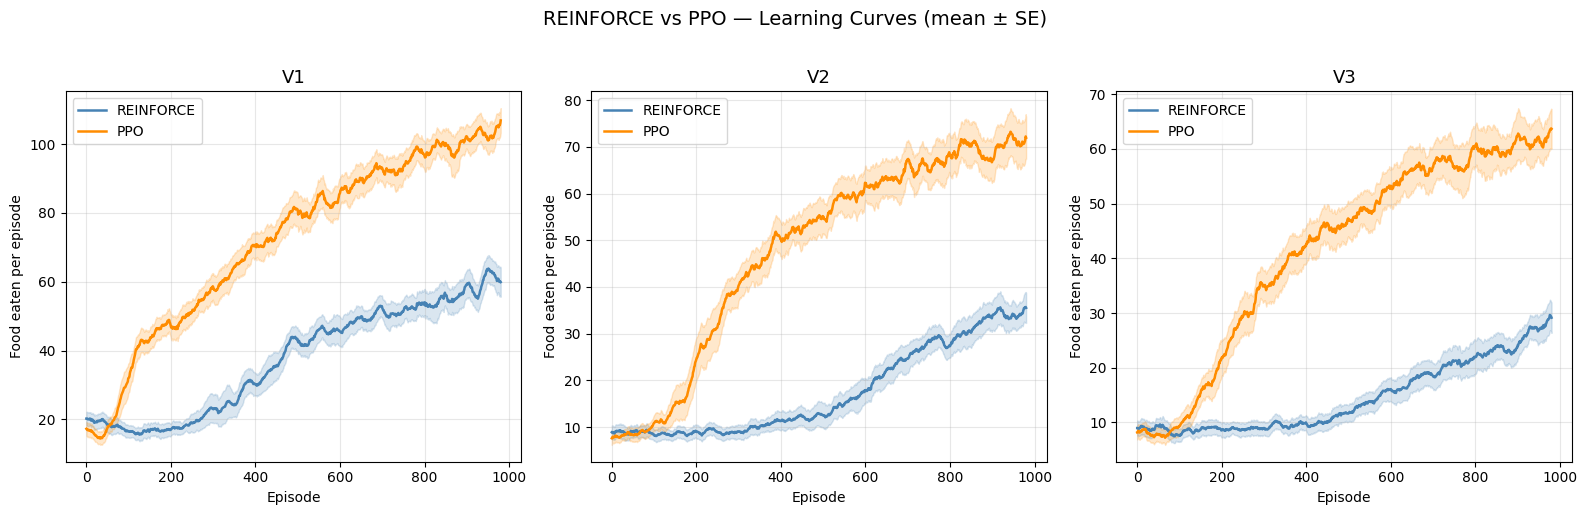

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, variant in zip(axes, VARIANTS):
    for label, data in [("REINFORCE", reinforce_results[variant]),
                        ("PPO",       ppo_results[variant])]:
        mean = data.mean(axis=0)
        se = data.std(axis=0) / np.sqrt(N_SEEDS)
        sm = smooth(mean)
        ep = np.arange(len(sm))
        ax.plot(sm, color=COLORS[label], label=label, linewidth=1.8)
        ax.fill_between(ep,
                        smooth(mean - se),
                        smooth(mean + se),
                        alpha=0.2, color=COLORS[label])

    ax.set_title(f"{variant}", fontsize=13)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Food eaten per episode")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("REINFORCE vs PPO — Learning Curves (mean ± SE)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("comparison_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Performance

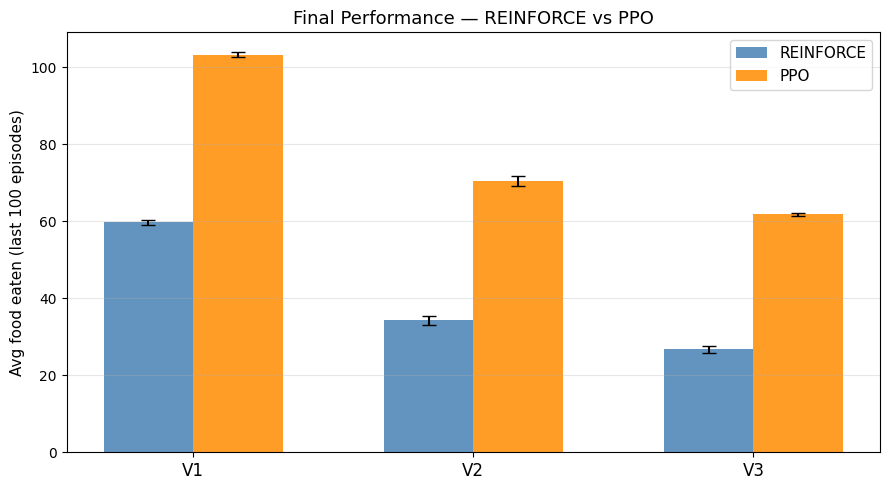

In [ ]:
LAST_N = 100

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(VARIANTS))
width = 0.32
labels = []

for i, (label, results) in enumerate(
        [("REINFORCE", reinforce_results), ("PPO", ppo_results)]):
    means, errs = [], []
    for v in VARIANTS:
        final = results[v][:, -LAST_N:].mean(axis=1)
        means.append(final.mean())
        errs.append(final.std() / np.sqrt(N_SEEDS))
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width,
                  label=label, color=COLORS[label],
                  yerr=errs, capsize=5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(VARIANTS, fontsize=12)
ax.set_ylabel("Avg food eaten (last 100 episodes)", fontsize=11)
ax.set_title("Final Performance — REINFORCE vs PPO", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_final_performance.png", dpi=150)
plt.show()

## Statistical Significance

In [15]:
print("Welch's t-test — final performance (last 100 eps):")
print(f"{'Variant':<6} {'REINFORCE':>12} {'PPO':>12} {'t':>8} {'p':>8} {'sig':>5}")
print("-" * 55)

for v in VARIANTS:
    r_final = reinforce_results[v][:, -LAST_N:].mean(axis=1)
    p_final = ppo_results[v][:, -LAST_N:].mean(axis=1)
    t, p = stats.ttest_ind(r_final, p_final, equal_var=False)
    sig = "***" if p < 0.001 else "**" if p < 0.01 \
        else "*" if p < 0.05 else "n.s."
    print(f"{v:<6} {r_final.mean():>12.2f} {p_final.mean():>12.2f} "
          f"{t:>8.2f} {p:>8.4f} {sig:>5}")

Welch's t-test — final performance (last 100 eps):
Variant    REINFORCE          PPO        t        p   sig
-------------------------------------------------------
V1            59.77       103.29   -44.89   0.0000   ***
V2            34.28        70.45   -17.79   0.0000   ***
V3            26.79        61.79   -29.92   0.0000   ***


## Sample Efficiency

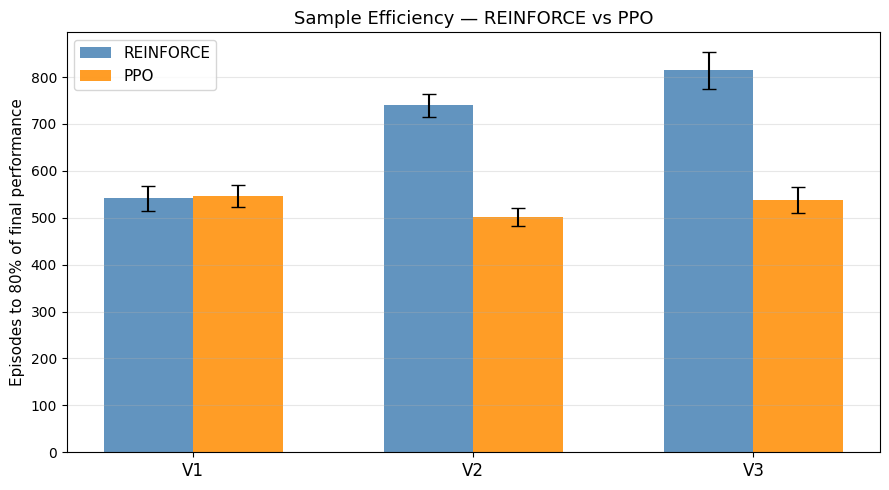

In [16]:
def episodes_to_threshold(food_hist, frac=0.8, w=20):
    sm = smooth(food_hist, w=w)
    threshold = frac * sm[-1]
    hits = np.where(sm >= threshold)[0]
    return hits[0] if len(hits) > 0 else len(food_hist)


fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(VARIANTS))

for i, (label, results) in enumerate(
        [("REINFORCE", reinforce_results), ("PPO", ppo_results)]):
    means, errs = [], []
    for v in VARIANTS:
        eff = [episodes_to_threshold(results[v][s]) for s in range(N_SEEDS)]
        means.append(np.mean(eff))
        errs.append(np.std(eff) / np.sqrt(N_SEEDS))
    offset = (i - 0.5) * 0.32
    ax.bar(x + offset, means, 0.32,
           label=label, color=COLORS[label],
           yerr=errs, capsize=5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(VARIANTS, fontsize=12)
ax.set_ylabel("Episodes to 80% of final performance", fontsize=11)
ax.set_title("Sample Efficiency — REINFORCE vs PPO", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_sample_efficiency.png", dpi=150)
plt.show()

## Stability — Variance Across Seeds Over Training

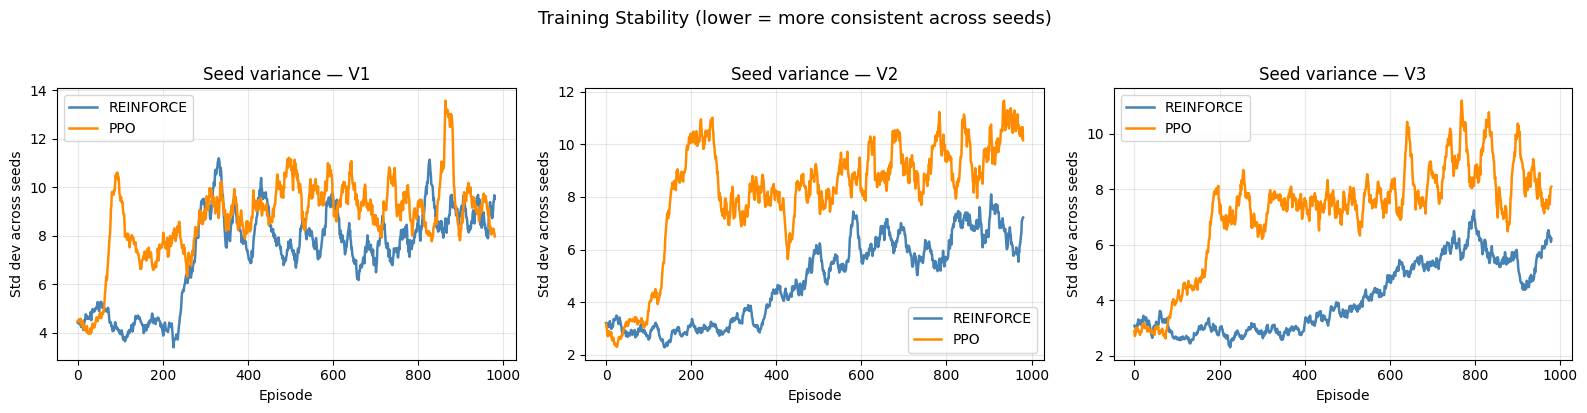

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, variant in zip(axes, VARIANTS):
    for label, data in [("REINFORCE", reinforce_results[variant]),
                        ("PPO",       ppo_results[variant])]:
        std_over_time = smooth(data.std(axis=0))
        ax.plot(std_over_time, color=COLORS[label],
                label=label, linewidth=1.8)

    ax.set_title(f"Seed variance — {variant}", fontsize=12)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Std dev across seeds")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training Stability (lower = more consistent across seeds)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparison_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## Degradation Under Noise — V2 → V3

Performance degradation V2 -> V3 (stochastic transitions):
Algorithm       V2 mean    V3 mean       Drop     Drop %
--------------------------------------------------
REINFORCE         34.28      26.79       7.49      21.9%
PPO               70.45      61.79       8.67      12.3%


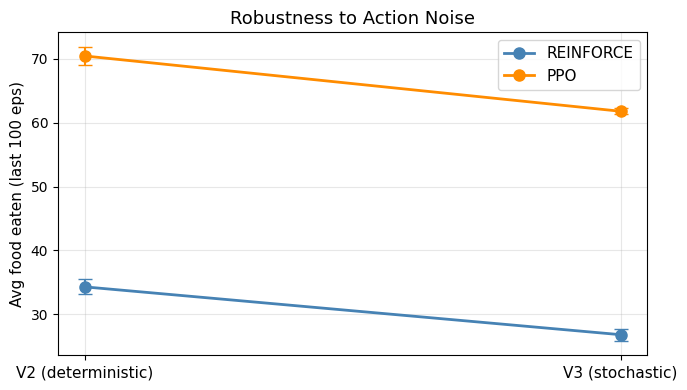

In [18]:
print("Performance degradation V2 -> V3 (stochastic transitions):")
print(f"{'Algorithm':<12} {'V2 mean':>10} {'V3 mean':>10} {'Drop':>10} {'Drop %':>10}")
print("-" * 50)

for label, results in [("REINFORCE", reinforce_results),
                       ("PPO",       ppo_results)]:
    v2 = results["V2"][:, -LAST_N:].mean(axis=1).mean()
    v3 = results["V3"][:, -LAST_N:].mean(axis=1).mean()
    drop = v2 - v3
    drop_p = 100 * drop / v2 if v2 > 0 else float("nan")
    print(f"{label:<12} {v2:>10.2f} {v3:>10.2f} "
          f"{drop:>10.2f} {drop_p:>9.1f}%")

# Visual
fig, ax = plt.subplots(figsize=(7, 4))
for i, (label, results) in enumerate(
        [("REINFORCE", reinforce_results), ("PPO", ppo_results)]):
    v2_scores = results["V2"][:, -LAST_N:].mean(axis=1)
    v3_scores = results["V3"][:, -LAST_N:].mean(axis=1)
    ax.plot([0, 1], [v2_scores.mean(), v3_scores.mean()],
            "o-", color=COLORS[label], label=label, linewidth=2,
            markersize=8)
    ax.errorbar([0, 1],
                [v2_scores.mean(), v3_scores.mean()],
                yerr=[v2_scores.std()/np.sqrt(N_SEEDS),
                      v3_scores.std()/np.sqrt(N_SEEDS)],
                fmt="none", color=COLORS[label], capsize=5)

ax.set_xticks([0, 1])
ax.set_xticklabels(["V2 (deterministic)", "V3 (stochastic)"], fontsize=11)
ax.set_ylabel("Avg food eaten (last 100 eps)", fontsize=11)
ax.set_title("Robustness to Action Noise", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_noise_degradation.png", dpi=150)
plt.show()

## Summary

In [19]:
print("=" * 72)
print(f"{'':20} {'V1':>16} {'V2':>16} {'V3':>16}")
print("=" * 72)

for label, results in [("REINFORCE", reinforce_results),
                       ("PPO",       ppo_results)]:
    final_means = [
        results[v][:, -LAST_N:].mean(axis=1).mean()
        for v in VARIANTS
    ]
    final_stds = [
        results[v][:, -LAST_N:].mean(axis=1).std() / np.sqrt(N_SEEDS)
        for v in VARIANTS
    ]
    row = f"{label + ' final food':<20}"
    for m, s in zip(final_means, final_stds):
        row += f"  {m:6.1f} ± {s:4.1f}"
    print(row)

print("-" * 72)

for label, results in [("REINFORCE", reinforce_results),
                       ("PPO",       ppo_results)]:
    eff_means = []
    for v in VARIANTS:
        eff = [episodes_to_threshold(results[v][s]) for s in range(N_SEEDS)]
        eff_means.append(np.mean(eff))
    row = f"{label + ' sample eff.':<20}"
    for m in eff_means:
        row += f"  {m:>14.0f}  "
    print(row)

print("=" * 72)

                                   V1               V2               V3
REINFORCE final food    59.8 ±  0.6    34.3 ±  1.2    26.8 ±  0.9
PPO final food         103.3 ±  0.6    70.5 ±  1.4    61.8 ±  0.5
------------------------------------------------------------------------
REINFORCE sample eff.             541               740               814  
PPO sample eff.                  547               502               538  


## Policy Visualization — Trajectories & Behavior

In [20]:

# Define minimal network classes for loading
class PolicyNetwork(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
            nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        return self.net(x)
    
    def select_action(self, obs):
        obs_t = torch.FloatTensor(obs).unsqueeze(0)
        probs = self.forward(obs_t).squeeze(0)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)

class ActorCritic(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(obs_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
        )
        self.actor = nn.Linear(hidden_size, n_actions)
        self.critic = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        features = self.trunk(x)
        logits = self.actor(features)
        value = self.critic(features).squeeze(-1)
        return logits, value

# Load trained policies
reinforce_policies = {}
ppo_policies = {}

for variant in VARIANTS:
    # REINFORCE
    try:
        p = PolicyNetwork(25, 4)
        p.load_state_dict(torch.load(f"reinforce_policy_{variant}.pt", weights_only=True))
        p.eval()
        reinforce_policies[variant] = p
    except Exception as e:
        print(f"REINFORCE {variant}: {e}")
    
    # PPO
    try:
        ac = ActorCritic(25, 4)
        ac.load_state_dict(torch.load(f"ppo_policy_{variant}.pt", weights_only=True))
        ac.eval()
        ppo_policies[variant] = ac
    except Exception as e:
        print(f"PPO {variant}: {e}")

print("Policies loaded.")
print(f"REINFORCE: {list(reinforce_policies.keys())}")
print(f"PPO: {list(ppo_policies.keys())}")


Policies loaded.
REINFORCE: ['V1', 'V2', 'V3']
PPO: ['V1', 'V2', 'V3']


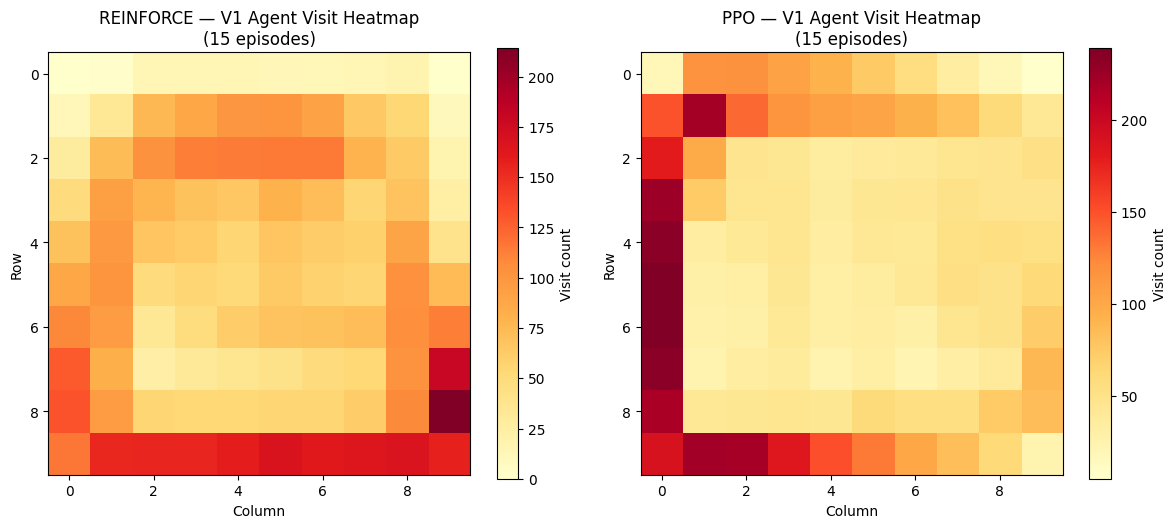

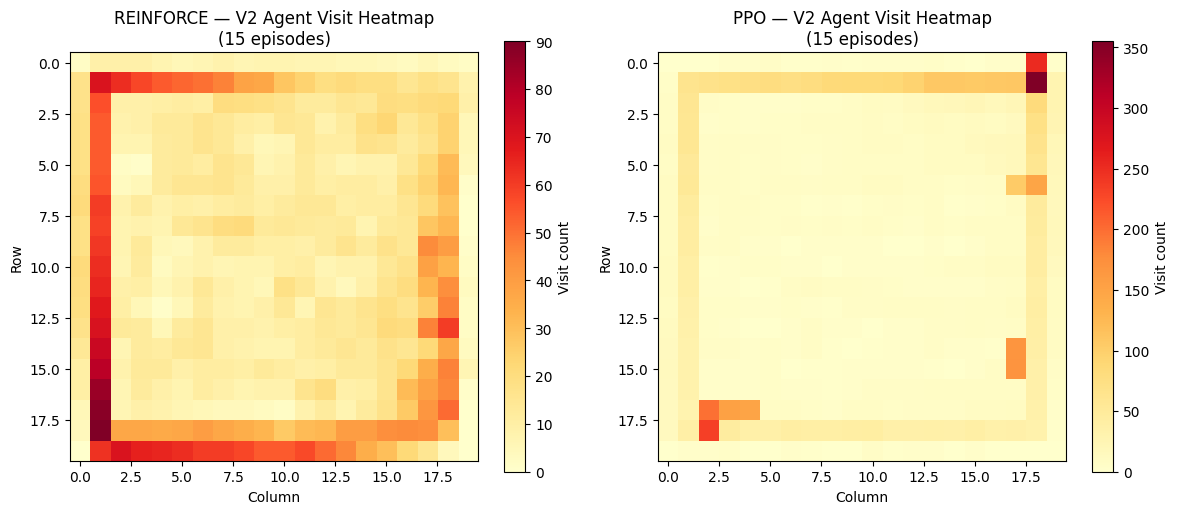

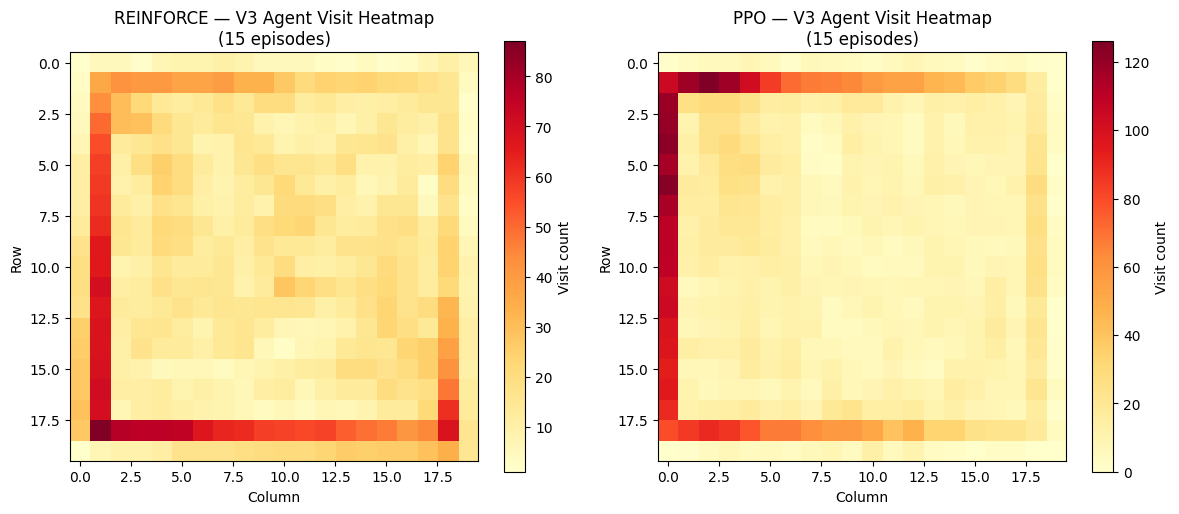

In [ ]:

def rollout_trajectory(env, policy, use_ppo=False, seed=None):
    """Collect agent positions during one episode."""
    env.rng = np.random.default_rng(seed)
    obs = env.reset()
    trajectory = [tuple(env.agent_pos)]
    done = False
    
    with torch.no_grad():
        while not done:
            if use_ppo:
                obs_t = torch.FloatTensor(obs).unsqueeze(0)
                logits, _ = policy(obs_t)
                action = logits.argmax(dim=-1).item()
            else:  # REINFORCE
                action, _ = policy.select_action(obs)
            
            obs, _, done, _ = env.step(action)
            trajectory.append(tuple(env.agent_pos))
    
    return trajectory


def visualize_trajectories(variant, n_rollouts=10, max_episodes=3):
    """Show agent trajectories for REINFORCE and PPO side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (ax, algo, policy_dict) in enumerate([
        (axes[0], "REINFORCE", reinforce_policies),
        (axes[1], "PPO", ppo_policies)
    ]):
        if variant not in policy_dict:
            ax.text(0.5, 0.5, f"{algo} not available", ha="center", va="center")
            continue
        
        policy = policy_dict[variant]
        env = ForagingEnv.make(variant, seed=99)
        grid_size = env.grid_size
        
        # Heatmap of visit counts
        visit_count = np.zeros((grid_size, grid_size))
        
        for ep in range(n_rollouts):
            traj = rollout_trajectory(env, policy, use_ppo=(algo=="PPO"), seed=99+ep)
            for r, c in traj:
                if 0 <= r < grid_size and 0 <= c < grid_size:
                    visit_count[r, c] += 1
        
        im = ax.imshow(visit_count, cmap="YlOrRd", origin="upper", interpolation="nearest")
        ax.set_title(f"{algo} — {variant} Agent Visit Heatmap\n({n_rollouts} episodes)", fontsize=12)
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        plt.colorbar(im, ax=ax, label="Visit count")
    
    plt.tight_layout()
    plt.savefig(f"policy_trajectories_{variant}.png", dpi=150, bbox_inches="tight")
    plt.show()


for variant in VARIANTS:
    visualize_trajectories(variant, n_rollouts=15)


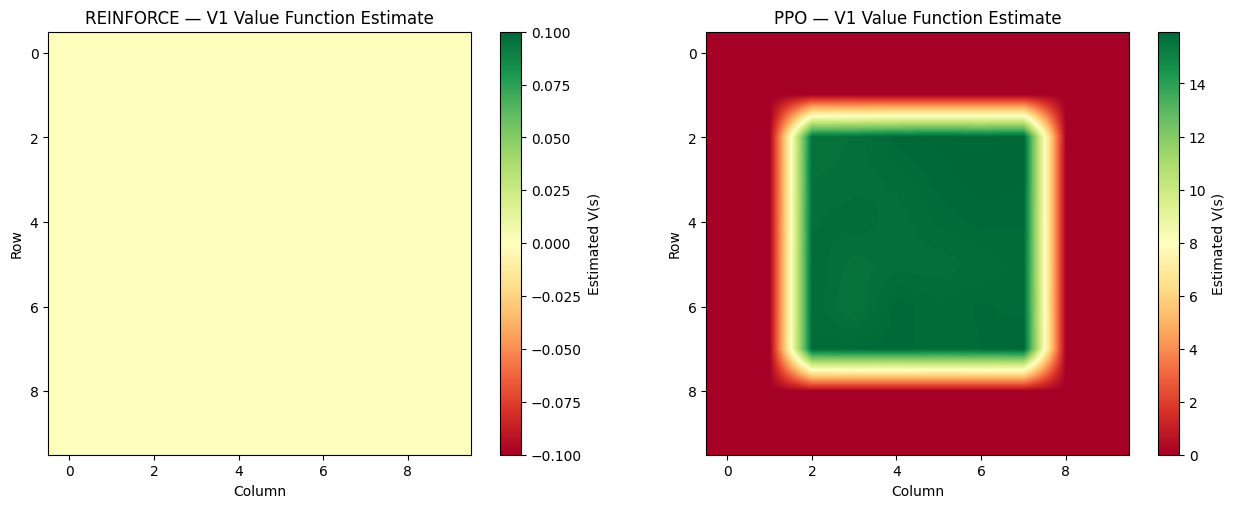

In [ ]:

def visualize_value_function(variant):
    """Estimate value function by sampling positions on grid."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    for idx, (ax, algo, policy_dict) in enumerate([
        (axes[0], "REINFORCE", reinforce_policies),
        (axes[1], "PPO", ppo_policies)
    ]):
        if variant not in policy_dict:
            ax.text(0.5, 0.5, f"{algo} not available", ha="center", va="center")
            continue
        
        policy = policy_dict[variant]
        env = ForagingEnv.make(variant, seed=0)
        grid_size = env.grid_size
        vision_r = env.vision_radius
        
        value_map = np.zeros((grid_size, grid_size))
        count_map = np.zeros((grid_size, grid_size))
        
        for _ in range(30):
            env.reset()
            for r in range(vision_r, grid_size - vision_r):
                for c in range(vision_r, grid_size - vision_r):
                    env.agent_pos = [r, c]
                    obs = env._get_obs()
                    obs_t = torch.FloatTensor(obs).unsqueeze(0)
                    
                    with torch.no_grad():
                        if algo == "PPO":
                            _, value = policy(obs_t)
                            val = value.item()
                        else:
                            val = 0.0
                    
                    value_map[r, c] += val
                    count_map[r, c] += 1
        
        # Average
        value_map = np.divide(value_map, count_map, where=count_map > 0, out=np.zeros_like(value_map))
        
        im = ax.imshow(value_map, cmap="RdYlGn", origin="upper", interpolation="bilinear")
        ax.set_title(f"{algo} — {variant} Value Function Estimate", fontsize=12)
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        plt.colorbar(im, ax=ax, label="Estimated V(s)")
    
    plt.tight_layout()
    plt.savefig(f"policy_value_function_{variant}.png", dpi=150, bbox_inches="tight")
    plt.show()


for variant in VARIANTS[:1]:
    visualize_value_function(variant)


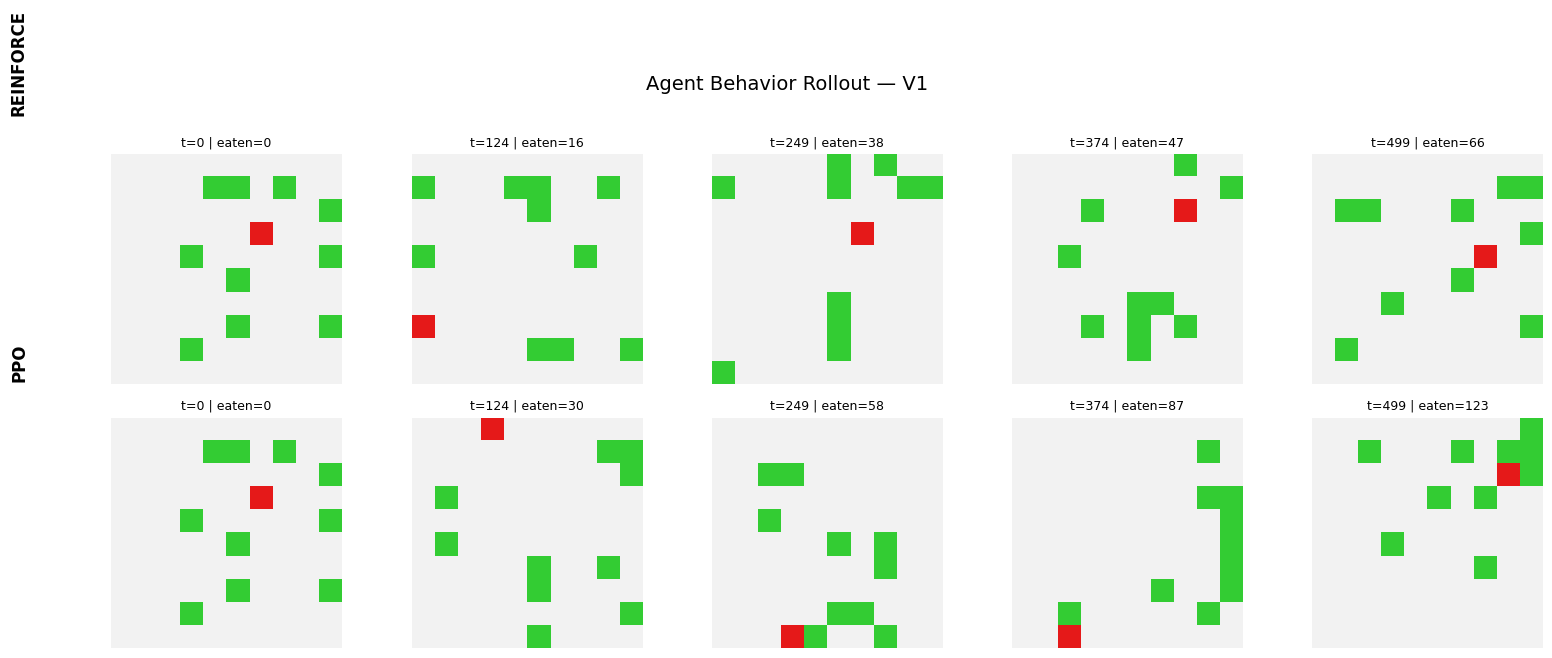

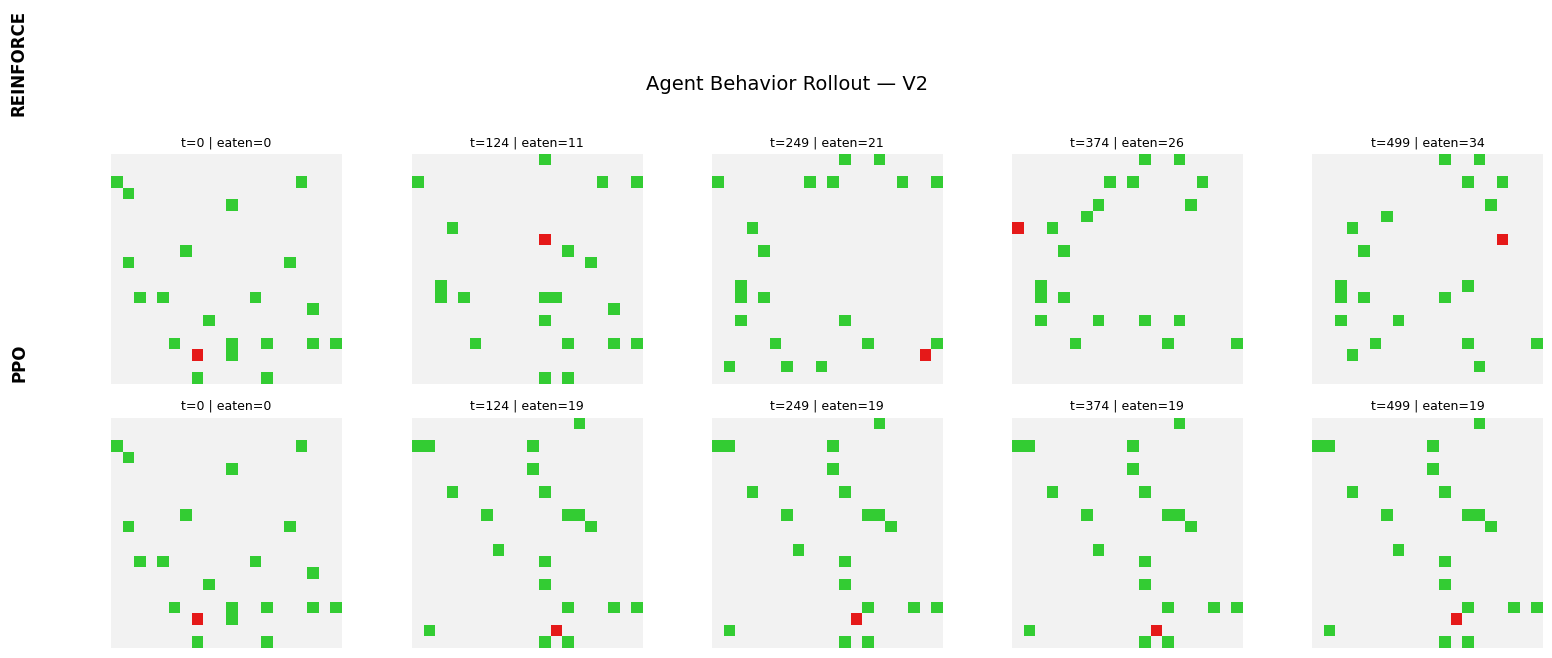

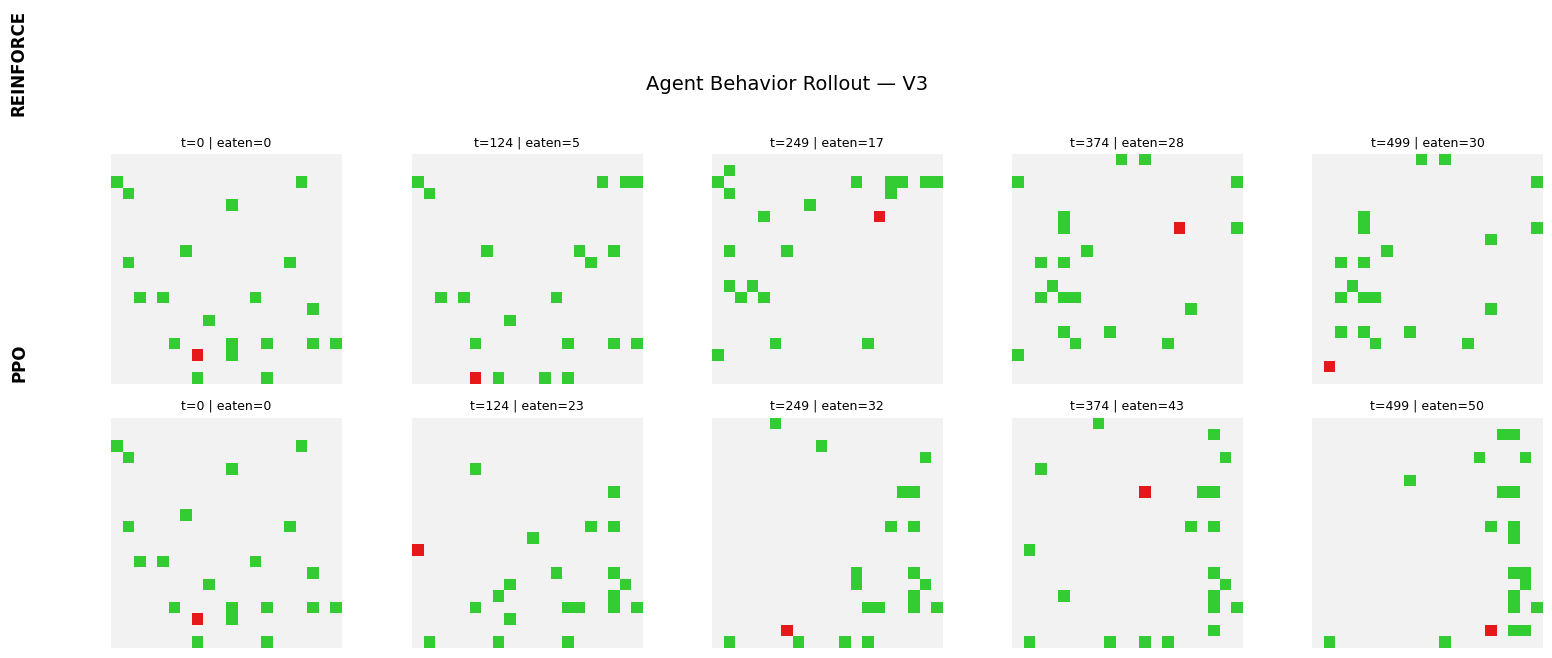

In [ ]:

def visualize_behavior_rollout(variant, n_frames=5):
    """Show snapshots of agent behavior during one episode."""
    fig, axes = plt.subplots(2, n_frames, figsize=(16, 6))
    
    for idx, (row_idx, algo, policy_dict) in enumerate([
        (0, "REINFORCE", reinforce_policies),
        (1, "PPO", ppo_policies)
    ]):
        if variant not in policy_dict:
            for j in range(n_frames):
                axes[row_idx, j].text(0.5, 0.5, f"{algo} not available", ha="center", va="center")
            continue
        
        policy = policy_dict[variant]
        env = ForagingEnv.make(variant, seed=100)
        obs = env.reset()
        done = False
        frame_indices = np.linspace(0, env.max_steps - 1, n_frames, dtype=int)
        frame_count = 0
        displayed = 0
        
        with torch.no_grad():
            while not done and displayed < n_frames:
                if frame_count in frame_indices:
                    img = np.ones((env.grid_size, env.grid_size, 3)) * 0.95
                    
                    # Food
                    for r, c in env.food_positions:
                        img[r, c] = [0.2, 0.8, 0.2]
                    
                    # Agent
                    ar, ac = env.agent_pos
                    img[ar, ac] = [0.9, 0.1, 0.1]
                    
                    axes[row_idx, displayed].imshow(img, origin="upper")
                    axes[row_idx, displayed].set_title(
                        f"t={frame_count} | eaten={env.total_food_eaten}",
                        fontsize=9
                    )
                    axes[row_idx, displayed].axis("off")
                    displayed += 1
                
                if algo == "PPO":
                    obs_t = torch.FloatTensor(obs).unsqueeze(0)
                    logits, _ = policy(obs_t)
                    action = logits.argmax(dim=-1).item()
                else:
                    action, _ = policy.select_action(obs)
                
                obs, _, done, _ = env.step(action)
                frame_count += 1
        
        fig.text(0.02, 0.5 + (0.5 - row_idx * 0.5), algo, ha="center", va="center", 
                fontsize=12, fontweight="bold", rotation=90)
    
    plt.suptitle(f"Agent Behavior Rollout — {variant}", fontsize=14, y=0.98)
    plt.tight_layout(rect=[0.05, 0, 1, 0.96])
    plt.savefig(f"policy_behavior_{variant}.png", dpi=150, bbox_inches="tight")
    plt.show()


for variant in VARIANTS:
    visualize_behavior_rollout(variant, n_frames=5)
